<h1> Experiment coincidence against photon frequency </h1>

In [ ]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_frequency import run_coincidence_vs_frequency

<h2> Execute the experiment </h2>

To assess the impact of the frequency window, we run the experiment three times. Each experiment corresponds to a given frequency window $[\Lambda_{\rm IR}, \Lambda_{\rm UV}]$

In [45]:
#Parameters of the simulation
L = 50

param_photons_bis = {'delta_k': [0.05*pi, 0.05*pi],
                 'x_0': [-L/4, -L/4]}  #the photon frequency will be varied in this experiment

param_cavity = {'omega_0': 10*pi, 'gamma': 5*pi, 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.01}

#Define an array of frequencies around the cavity bare esonance
nb_freq = 15
omega_p_tab = np.linspace(param_cavity['omega_0'] - 0.8*param_cavity['gamma'], param_cavity['omega_0'] + 0.8*param_cavity['gamma'], nb_freq)

#Assess the curve of reflection vs frequency of different frequency windows

frequency_windows = [
    (0, 20*pi),
    (0, 18*pi),
    (0, 16*pi)
]

Run the experiment 6 times for each frequency window

In [46]:
for i in range(len(frequency_windows)):
    index_experiment = i+1
    print("Running frequency window number ", index_experiment, " out of ", len(frequency_windows))
    cutoffs = {'ir_cutoff': frequency_windows[i][0], 'uv_cutoff': frequency_windows[i][1]}
    #Run the experiment

    frequency_values, coincidence_tab = run_coincidence_vs_frequency(param_photons_bis, param_cavity, param_time_evol, omega_p_tab, cutoffs, 
                                                                         index_experiment=index_experiment, store_results=True, progress=True)

Running frequency window number  1  out of  3


100%|██████████| 15/15 [27:20<00:00, 109.34s/it]


Running frequency window number  2  out of  3


100%|██████████| 15/15 [21:58<00:00, 87.92s/it]


Running frequency window number  3  out of  3


100%|██████████| 15/15 [17:35<00:00, 70.38s/it]


<h2> Plot the results </h2>

Load the data

In [88]:
index_experiment = 3
ir_cutoff = frequency_windows[index_experiment-1][0]
uv_cutoff = frequency_windows[index_experiment-1][1]

data_file = f"../results/csv_files/coincidence_vs_frequency_{index_experiment}.csv"
df = pd.read_csv(data_file)
photon_frequency_tab = df['photon_frequency_tab'].to_numpy()
coincidence_tab = df['final_reflection_tab'].to_numpy()

Generate theoretical bare curve (prediction from $\omega_0$ and $\gamma$) and physical curve (prediction from $\omega_A$ and $\Gamma$)

In [89]:
frequency_tab_theory = np.linspace(param_cavity['omega_0'] - param_cavity['gamma'], param_cavity['omega_0'] + param_cavity['gamma'], 100)

#Bare prediction
R_theory_bare = 1 / (1 + ((frequency_tab_theory - param_cavity['omega_0'])/ (param_cavity['gamma']/2))**2)
coincidence_bare = 1 - 4*R_theory_bare*(1-R_theory_bare)

#Physical prediction with Lamb shift and renormalized decay rate
prefactor = 1/(1+param_cavity['gamma']/(2*pi)*(1/(ir_cutoff - param_cavity['omega_0']) - 1/(uv_cutoff - param_cavity['omega_0'])))
omega_A = param_cavity['omega_0'] - param_cavity['gamma'] / (2*pi) * np.log((uv_cutoff-param_cavity['omega_0'])/(param_cavity['omega_0'] - ir_cutoff)) * prefactor
Gamma = param_cavity['gamma'] * prefactor

R_theory_physical = 1 / (1 + ((frequency_tab_theory - omega_A)/ (Gamma/2))**2)
coincidence_physical = 1 - 4*R_theory_physical*(1-R_theory_physical)

Create the figure

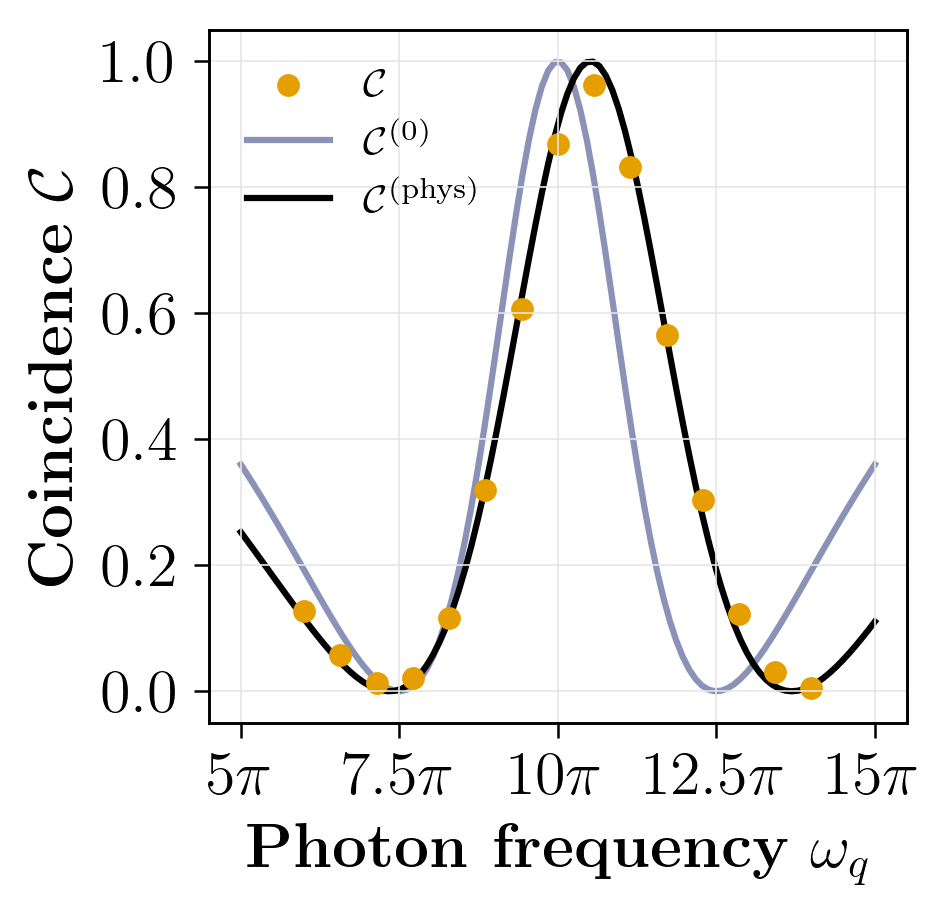

In [90]:
show_bare_curve = True
show_physical_curve = True

# Création de la figure
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

color_bare = "#3E4A89"
color_data = "#E69F00"

#data points
ax.scatter(photon_frequency_tab, coincidence_tab, label=r'$\mathcal{C}$', color=color_data, s=20)

# Theoretical curves
if show_bare_curve and not show_physical_curve: 
    ax.plot(frequency_tab_theory, coincidence_bare, color=color_bare, alpha=0.8, zorder = -1, label=r'$\mathcal{C}^{(0)}$')
if show_bare_curve and show_physical_curve:
    #small label change for the bare curve in this context 
    ax.plot(frequency_tab_theory, coincidence_bare, color=color_bare, alpha=0.6, zorder = -1, label=r'$\mathcal{C}^{(0)}$')
    ax.plot(frequency_tab_theory, coincidence_physical, color='black', alpha=1, zorder = -1, label=r'$\mathcal{C}^{(\rm phys)}$')


# Labels, limites et grille
ax.set_xlabel(r'\textbf{Photon frequency} $\omega_q$', fontsize=10)
ax.set_xticks([param_cavity['omega_0'] - param_cavity['gamma'], param_cavity['omega_0'] - param_cavity['gamma']/2, param_cavity['omega_0'], param_cavity['omega_0'] + param_cavity['gamma']/2, param_cavity['omega_0'] + param_cavity['gamma']])
ax.set_xticklabels([r"$5\pi$",r"$7.5\pi$",r"$10\pi$",r"$12.5\pi$",r"$15\pi$"])

ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=10)
ax.set_ylim(-0.05, 1.05)
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="upper left", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

if show_bare_curve and not show_physical_curve:
    plt.savefig("../results/fig/coincidence_multi_cutoff_experiment_"+str(index_experiment)+".pdf", bbox_inches="tight")
if show_bare_curve and show_physical_curve:
    plt.savefig("../results/fig/coincidence_multi_cutoff_experiment_adjusted_"+str(index_experiment)+".pdf", bbox_inches="tight")

plt.show()